## NMD Models: Deposit Rate Model

This notebook showns how to model the relationship between deposit rate and market rate with 3 difference methodologies.

| Method | Description |
|---|---|
| Beta Regression | OLS regression of deposit rate and market rate, the beta is pass-through rate |
| Threshold | Asymmetric adjustment speed, expect slow increase and fast drop |
| Jarrow-Van Deventer | Model changes in deposit rate instead of levels |

In [ ]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [ ]:
# Import libraries
import warnings
import pandas as pd
import pickle
import sys; sys.path.insert(0, "..")

from src.deposit_rate_model import deposit_rate_linear, deposit_rate_threshold, deposit_rate_jvd
from src.plot_function import plot_deposit_rate_results

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [4]:
# Load Data
df = pd.read_parquet(
    '../data/raw/nmd_data.parquet',
    engine = "pyarrow"
)

# Extract rates
deposit_rate = df["deposit_rate"]
market_rate = df["market_rate"]

# Show
print("=" * 60)
print(f"{"Observations":<{15}}: {len(df)}")
print(f"{"Deposit rate":<{15}}: mean = {deposit_rate.mean():.2%}, std = {deposit_rate.std():.2%}")
print(f"{"Market rate":<{15}}: mean = {market_rate.mean():.2%}, std = {market_rate.std():.2%}")
print("=" * 60)

# Show table
df[["deposit_rate", "market_rate"]].head(5)

Observations   : 150
Deposit rate   : mean = 0.89%, std = 0.18%
Market rate    : mean = 4.88%, std = 0.69%


,deposit_rate,market_rate
date,,
2012-01-31,0.011,0.055
2012-02-29,0.011,0.048
2012-03-31,0.011,0.047
2012-04-30,0.012,0.049
2012-05-31,0.010,0.043


In [5]:
# Beta regression model
linear_result = deposit_rate_linear(
    deposit_rate = deposit_rate,
    market_rate = market_rate
)

# Result
print("=" * 60)
print(f"{"Alpha":<{15}}: {linear_result["alpha"]:.4f}")
print(f"{"**Beta**":<{15}}: {linear_result["beta"]:.4f}")
print(f"{"R-Square":<{15}}: {linear_result["r2"]:.2%}")
print("=" * 60)

# Export
with open("../model/beta_model.pkl", "wb") as file:
    pickle.dump(linear_result, file)

Alpha          : -0.0012
**Beta**       : 0.2072
R-Square       : 60.75%


In [6]:
# Translate deposit rate beta into IRRBB repricing bucket split.
"""
Under IRRBB, the beta coefficient from the OLS (Beta) deposit rate model
determines what fraction of deposits are treated as rate-sensitive
and placed in the overnight (immediate repricing) bucket.

Interpretation:
    - beta fraction reprices immediately --> overnight bucket
    - (1 - beta) fraction is behaviourally sticky --> behavioural maturity bucket

    This is used when constructing the repricing gap report for EVE and NII
    sensitivity analysis.
"""

# Calculation
total_balance = df["balance"].iloc[-1]
beta = linear_result["beta"]

overnight = beta * total_balance
behavioural = (1 - beta) * total_balance

# To DataFrame
result = pd.DataFrame(
    [
        {
            "Bucket": "Overnight (Sensitive)",
            "Balance": overnight,
            "pct": f"{beta:.2%}"
        },
        {
            "Bucket": "Behavioural (Sticky)",
            "Balance": behavioural,
            "pct": f"{1 - beta:.2%}"
        },
    ]
).set_index("Bucket")

# Show result
result

,Balance,pct
Bucket,,
Overnight (Sensitive),1044.033,20.72%
Behavioural (Sticky),3995.617,79.28%


In [7]:
# Threshold model
threshold_result = deposit_rate_threshold(
    deposit_rate = deposit_rate,
    market_rate = market_rate,
    beta_ols = linear_result["beta"]
)

# Result
print("=" * 60)
print(f"{"Converged":<{15}}: {threshold_result["converged"]} (SSE: {threshold_result["sse"]:.4f})")
print(f"{"Beta":<{15}}: {threshold_result["beta"]:.4f} (from Beta model *Pass-through rate*)")
print(f"{"Spread":<{15}}: {threshold_result["g"]:.4f}")
print(f"{"lambda+":<{15}}: {threshold_result["lambda_up"]:.4f} (Upward adjustment speed)")
print(f"{"lambda-":<{15}}: {threshold_result["lambda_down"]:.4f} (Downward adjustment speed)")
print("=" * 60)

print("Asymmetry check")
if threshold_result["lambda_down"] > threshold_result["lambda_up"]:
    print("lambda- > lambda+ means the Bank cuts rates faster than raises it")
    print(f"  lambda- / lambda+ = {threshold_result["lambda_down"] / threshold_result["lambda_up"]:.2f}x")
else:
    print("Recheck model")
print("=" * 60)

# Export
with open("../model/threshold_model.pkl", "wb") as file:
    pickle.dump(threshold_result, file)

Converged      : True (SSE: 0.0001)
Beta           : 0.2072 (from Beta model *Pass-through rate*)
Spread         : 0.0008
lambda+        : 0.1533 (Upward adjustment speed)
lambda-        : 0.4489 (Downward adjustment speed)
Asymmetry check
lambda- > lambda+ means the Bank cuts rates faster than raises it
  lambda- / lambda+ = 2.93x


In [8]:
# Jarrow-Van Deventer model
jvd_result = deposit_rate_jvd(
    deposit_rate = deposit_rate,
    market_rate = market_rate
)

# Result
print("=" * 60)
print(f"{"Beta 2":<{15}}: {jvd_result["beta_2"]:.4f} (Intensity of rate adjustment)")
print(f"{"p-value":<{15}}: {jvd_result['pvalue']['beta_2']:.4f}")
print(f"{"R-Square":<{15}}: {jvd_result["r2"]:.4f}")
print("=" * 60)

# Export
with open("../model/jvd_model.pkl", "wb") as file:
    pickle.dump(jvd_result, file)

Beta 2         : 0.0797 (Intensity of rate adjustment)
p-value        : 0.0000
R-Square       : 0.1967


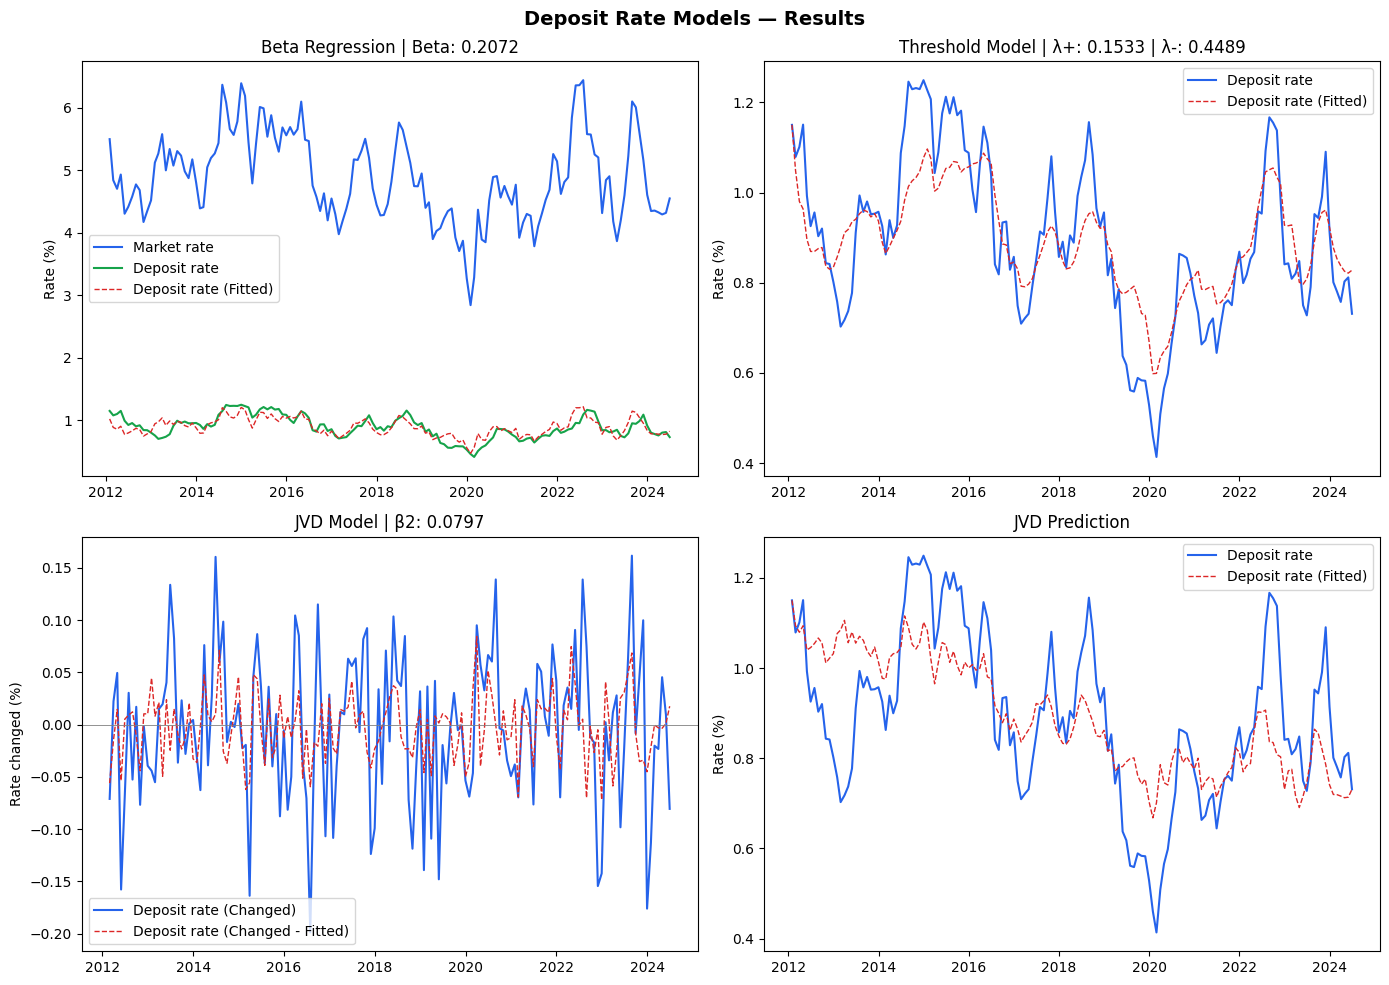

In [9]:
# Plot visualise results
plot_deposit_rate_results(
    deposit_rate = deposit_rate,
    market_rate = market_rate,
    linear_result = linear_result,
    threshold_result = threshold_result,
    jvd_result = jvd_result
)